# Atelier Séance 2 - Démo Classification sur le Dataset Titanic

**Cours:** IA/ML/DL - M2 DEV G1 EFREI Paris  
**Instructeur:** Babacar GUEYE  
**Format:** Démonstration guidée (pipeline complet)  

## Objectifs

- Montrer un pipeline ML complet: chargement → nettoyage → entraînement → évaluation
- Appliquer k-NN et régression logistique sur des données réelles
- Illustrer l'impact du choix de l'hyperparamètre `k`
- Comparer les modèles avec des métriques de classification
- Conclure avec des déductions métier et techniques

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print("✓ Imports réussis")

✓ Imports réussis


## Partie 1: Chargement et Nettoyage du Dataset Titanic

Le dataset Titanic contient des informations sur les passagers et on doit prédire s'ils ont survécu ou non.

**Features disponibles:**
- Pclass: Classe du ticket (1, 2, ou 3)
- Sex: Genre (male, female)
- Age: Âge du passager
- SibSp: Nombre de frères/sœurs/conjoints à bord
- Parch: Nombre de parents/enfants à bord
- Fare: Prix du ticket
- Embarked: Port d'embarquement (C, Q, S)

**Target:**
- Survived: 1 si survécu, 0 sinon

In [3]:
# Charger le dataset depuis seaborn
df = sns.load_dataset('titanic')

print("Dataset Titanic chargé!")
print(f"\nShape: {df.shape}")
print(f"\nPremières lignes:")
print(df.head())
print(f"\nTypes de données:")
print(df.dtypes)
print(f"\nValeurs manquantes:")
print(df.isnull().sum())

Dataset Titanic chargé!

Shape: (891, 15)

Premières lignes:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Types de données:
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             i

In [ ]:
""" # Charger le dataset depuis seaborn
df = sns.load_dataset("titanic")

# Affichage complet (attention: très verbeux)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
display(df)

# (optionnel) revenir aux options par défaut
pd.reset_option("display.max_rows")
pd.reset_option("display.max_columns")

df.to_csv("titanic_full.csv", index=False)
print("Dataset exporté vers titanic_full.csv") """

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.00,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.00,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.00,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.00,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.00,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.00,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.00,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.00,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.00,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


Dataset exporté vers titanic_full.csv


In [4]:
# Statistiques descriptives
print("Statistiques descriptives:")
print(df.describe())
print(f"\nDistribution de la cible (Survived):")
print(df['survived'].value_counts())
print(f"\nProportions:")
print(df['survived'].value_counts(normalize=True))

Statistiques descriptives:
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000    0.000000
25%      0.000000    2.000000   20.125000    0.000000    0.000000    7.910400
50%      0.000000    3.000000   28.000000    0.000000    0.000000   14.454200
75%      1.000000    3.000000   38.000000    1.000000    0.000000   31.000000
max      1.000000    3.000000   80.000000    8.000000    6.000000  512.329200

Distribution de la cible (Survived):
survived
0    549
1    342
Name: count, dtype: int64

Proportions:
survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [5]:
# Faire une copie pour le nettoyage
df_clean = df.copy()

# Étape 1: Gestion des valeurs manquantes
# Evite chained-assignment warnings (pandas) avec assignation explicite
age_median = df_clean['age'].median()
embarked_mode = df_clean['embarked'].mode()[0]
df_clean['age'] = df_clean['age'].fillna(age_median)
df_clean['embarked'] = df_clean['embarked'].fillna(embarked_mode)

print("Valeurs manquantes après nettoyage:")
print(df_clean.isnull().sum())

Valeurs manquantes après nettoyage:
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [6]:
# Étape 2: Encodage des variables catégoriques
# Créer des encoders pour les variables catégoriques

# Encoder 'sex' (male -> 1, female -> 0)
le_sex = LabelEncoder()
df_clean['sex_encoded'] = le_sex.fit_transform(df_clean['sex'])

# Encoder 'embarked' (C, Q, S)
le_embarked = LabelEncoder()
df_clean['embarked_encoded'] = le_embarked.fit_transform(df_clean['embarked'])

print("Encodage des variables catégoriques:")
print(f"Sex: {dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))}")
print(f"Embarked: {dict(zip(le_embarked.classes_, le_embarked.transform(le_embarked.classes_)))}")

print(f"\nAperçu après encodage:")
print(df_clean[['sex', 'sex_encoded', 'embarked', 'embarked_encoded']].head())

Encodage des variables catégoriques:
Sex: {'female': np.int64(0), 'male': np.int64(1)}
Embarked: {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}

Aperçu après encodage:
      sex  sex_encoded embarked  embarked_encoded
0    male            1        S                 2
1  female            0        C                 0
2  female            0        S                 2
3  female            0        S                 2
4    male            1        S                 2


In [7]:
# Étape 3: Sélectionner les features et la cible
feature_cols = ['pclass', 'sex_encoded', 'age', 'sibsp', 'parch', 'fare', 'embarked_encoded']
X = df_clean[feature_cols].values
y = df_clean['survived'].values

print(f"Features sélectionnées: {feature_cols}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nPremières 5 lignes de X:")
print(X[:5])
print(f"\nPremières 5 valeurs de y:")
print(y[:5])

Features sélectionnées: ['pclass', 'sex_encoded', 'age', 'sibsp', 'parch', 'fare', 'embarked_encoded']

X shape: (891, 7)
y shape: (891,)

Premières 5 lignes de X:
[[ 3.      1.     22.      1.      0.      7.25    2.    ]
 [ 1.      0.     38.      1.      0.     71.2833  0.    ]
 [ 3.      0.     26.      0.      0.      7.925   2.    ]
 [ 1.      0.     35.      1.      0.     53.1     2.    ]
 [ 3.      1.     35.      0.      0.      8.05    2.    ]]

Premières 5 valeurs de y:
[0 1 1 1 0]


## Partie 2: Split Train/Test

Diviser les données en ensemble d'entraînement (80%) et ensemble de test (20%) avec stratification sur la cible.

In [8]:
# TODO: Effectuer le split train/test
# - test_size=0.2 (20% pour le test)
# - stratify=y (pour que les proportions de classes soient identiques dans train et test)
# - random_state=42 (pour reproductibilité)

# X_train, X_test, y_train, y_test = train_test_split(...)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Standardisation: indispensable pour k-NN (distance) et utile pour la régression logistique
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Ensemble d'entraînement: {X_train.shape[0]} exemples")
print(f"Ensemble de test: {X_test.shape[0]} exemples")
print(f"\nProportions dans train:")
unique_train, counts_train = np.unique(y_train, return_counts=True)
for cls, count in zip(unique_train, counts_train):
    print(f"  Classe {cls}: {count/len(y_train)*100:.1f}%")
print(f"\nProportions dans test:")
unique_test, counts_test = np.unique(y_test, return_counts=True)
for cls, count in zip(unique_test, counts_test):
    print(f"  Classe {cls}: {count/len(y_test)*100:.1f}%")

print(f"\nFeatures standardisées: train={X_train_scaled.shape}, test={X_test_scaled.shape}")

Ensemble d'entraînement: 712 exemples
Ensemble de test: 179 exemples

Proportions dans train:
  Classe 0: 61.7%
  Classe 1: 38.3%

Proportions dans test:
  Classe 0: 61.5%
  Classe 1: 38.5%

Features standardisées: train=(712, 7), test=(179, 7)


## Partie 3: Classification avec k-NN (k=5)

Entraîner un modèle k-NN avec k=5 voisins et évaluer sa performance.

In [9]:
# TODO: Entraîner un modèle KNeighborsClassifier avec k=5
# knn = KNeighborsClassifier(n_neighbors=5)
# knn.fit(X_train, y_train)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

print("✓ Modèle k-NN (k=5) entraîné")

✓ Modèle k-NN (k=5) entraîné


In [10]:
# TODO: Faire des prédictions sur l'ensemble de test
# y_pred_knn = knn.predict(X_test)

y_pred_knn = knn.predict(X_test_scaled)

print(f"Prédictions effectuées sur {len(y_pred_knn)} exemples")
print(f"Premières 10 prédictions: {y_pred_knn[:10]}")
print(f"Premières 10 vraies valeurs: {y_test[:10]}")

Prédictions effectuées sur 179 exemples
Premières 10 prédictions: [0 0 0 0 1 0 1 0 1 0]
Premières 10 vraies valeurs: [0 0 1 0 1 1 1 0 0 0]


In [11]:
# TODO: Calculer la précision (accuracy)
# acc_knn = accuracy_score(y_test, y_pred_knn)

acc_knn = accuracy_score(y_test, y_pred_knn)

print(f"Accuracy k-NN: {acc_knn:.4f} ({acc_knn*100:.2f}%)")

Accuracy k-NN: 0.8101 (81.01%)


In [12]:
# TODO: Afficher la matrice de confusion
# cm_knn = confusion_matrix(y_test, y_pred_knn)

cm_knn = confusion_matrix(y_test, y_pred_knn)

print("Matrice de Confusion (k-NN):")
print(cm_knn)
print(f"\nInterprétation:")
print(f"  Vrais Négatifs (TN): {cm_knn[0,0]} - Correctement prédits comme 0")
print(f"  Faux Positifs (FP): {cm_knn[0,1]} - Incorrectement prédits comme 1")
print(f"  Faux Négatifs (FN): {cm_knn[1,0]} - Incorrectement prédits comme 0")
print(f"  Vrais Positifs (TP): {cm_knn[1,1]} - Correctement prédits comme 1")

Matrice de Confusion (k-NN):
[[97 13]
 [21 48]]

Interprétation:
  Vrais Négatifs (TN): 97 - Correctement prédits comme 0
  Faux Positifs (FP): 13 - Incorrectement prédits comme 1
  Faux Négatifs (FN): 21 - Incorrectement prédits comme 0
  Vrais Positifs (TP): 48 - Correctement prédits comme 1


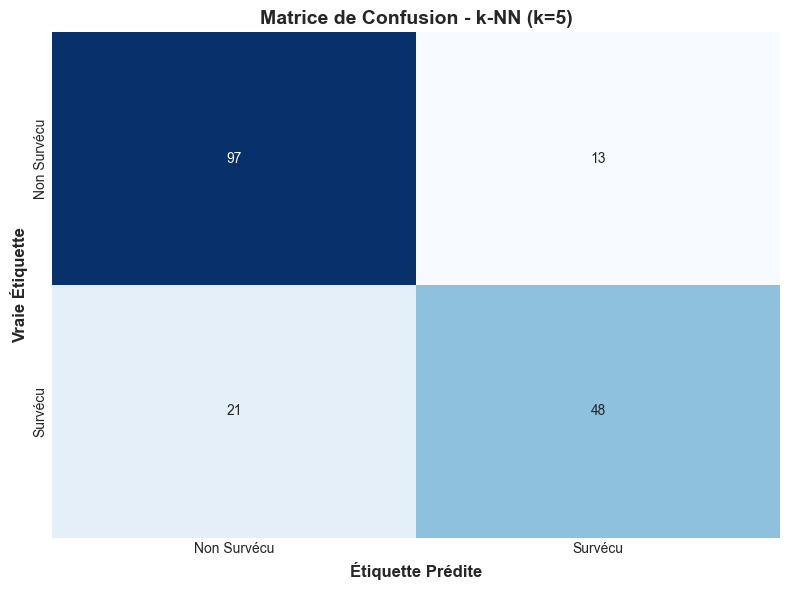

In [13]:
# Visualiser la matrice de confusion
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non Survécu', 'Survécu'],
            yticklabels=['Non Survécu', 'Survécu'],
            ax=ax, cbar_kws={'label': 'Nombre'})
ax.set_ylabel('Vraie Étiquette', fontsize=12, fontweight='bold')
ax.set_xlabel('Étiquette Prédite', fontsize=12, fontweight='bold')
ax.set_title('Matrice de Confusion - k-NN (k=5)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# TODO: Afficher le rapport de classification
# report_knn = classification_report(y_test, y_pred_knn)

report_knn = classification_report(y_test, y_pred_knn, 
                                    target_names=['Non Survécu', 'Survécu'])

print("Rapport de Classification (k-NN):")
print(report_knn)

Rapport de Classification (k-NN):
              precision    recall  f1-score   support

 Non Survécu       0.82      0.88      0.85       110
     Survécu       0.79      0.70      0.74        69

    accuracy                           0.81       179
   macro avg       0.80      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



## Partie 4: Variation du Paramètre k

Tester différentes valeurs de k et trouver la valeur optimale.

In [15]:
# TODO: Boucler sur différentes valeurs de k (1 à 21, nombres impairs)
# Pour chaque k, entraîner un modèle et calculer la précision sur le test

k_values = list(range(1, 22, 2))  # [1, 3, 5, 7, ..., 21]
train_scores = []
test_scores = []

for k in k_values:
    # Entraîner
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    
    # Évaluer
    train_score = knn_temp.score(X_train_scaled, y_train)
    test_score = knn_temp.score(X_test_scaled, y_test)
    
    train_scores.append(train_score)
    test_scores.append(test_score)
    
    print(f"k={k:2d} | Train Accuracy: {train_score:.4f} | Test Accuracy: {test_score:.4f}")

print(f"\n✓ Évaluation pour différentes valeurs de k terminée")

k= 1 | Train Accuracy: 0.9691 | Test Accuracy: 0.7709
k= 3 | Train Accuracy: 0.8750 | Test Accuracy: 0.8101
k= 5 | Train Accuracy: 0.8539 | Test Accuracy: 0.8101
k= 7 | Train Accuracy: 0.8455 | Test Accuracy: 0.8156
k= 9 | Train Accuracy: 0.8413 | Test Accuracy: 0.7933
k=11 | Train Accuracy: 0.8301 | Test Accuracy: 0.7989
k=13 | Train Accuracy: 0.8343 | Test Accuracy: 0.7989
k=15 | Train Accuracy: 0.8272 | Test Accuracy: 0.8101
k=17 | Train Accuracy: 0.8357 | Test Accuracy: 0.8101
k=19 | Train Accuracy: 0.8258 | Test Accuracy: 0.8156
k=21 | Train Accuracy: 0.8174 | Test Accuracy: 0.7989

✓ Évaluation pour différentes valeurs de k terminée


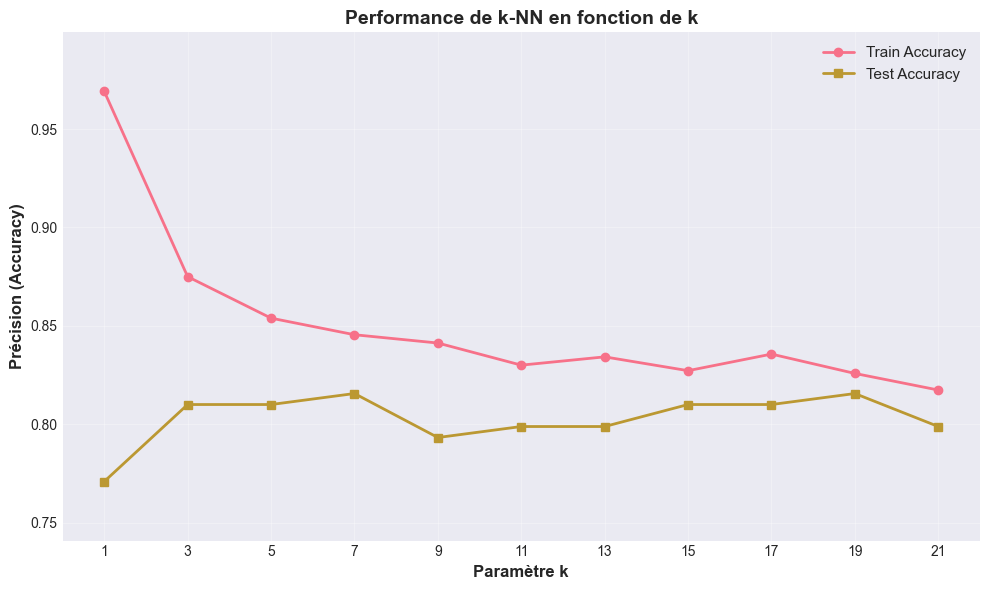

In [16]:
# TODO: Tracer un graphique montrant l'évolution de la précision en fonction de k

plt.figure(figsize=(10, 6))
plt.plot(k_values, train_scores, marker='o', label='Train Accuracy', linewidth=2)
plt.plot(k_values, test_scores, marker='s', label='Test Accuracy', linewidth=2)
plt.xlabel('Paramètre k', fontsize=12, fontweight='bold')
plt.ylabel('Précision (Accuracy)', fontsize=12, fontweight='bold')
plt.title('Performance de k-NN en fonction de k', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)

# Bornes dynamiques pour éviter de masquer les courbes si les scores changent
all_scores = train_scores + test_scores
y_min = max(0.0, min(all_scores) - 0.03)
y_max = min(1.0, max(all_scores) + 0.03)
plt.ylim([y_min, y_max])

plt.tight_layout()
plt.show()

In [18]:
# TODO: Trouver et afficher le k optimal (celui avec la meilleure précision de test)

optimal_k_idx = np.argmax(test_scores)
optimal_k = k_values[optimal_k_idx]
best_test_accuracy = test_scores[optimal_k_idx]
best_train_accuracy = train_scores[optimal_k_idx]

print(f"\n" + "="*50)
print(f"k OPTIMAL: {optimal_k}")
print(f"="*50)
print(f"Précision d'entraînement: {best_train_accuracy:.4f}")
print(f"Précision de test: {best_test_accuracy:.4f}")
print(f"Gap (surapprentissage): {best_train_accuracy - best_test_accuracy:.4f}")


k OPTIMAL: 7
Précision d'entraînement: 0.8455
Précision de test: 0.8156
Gap (surapprentissage): 0.0299


## Partie 5: Régression Logistique

Entraîner un modèle de régression logistique et le comparer à k-NN.

In [19]:
# TODO: Entraîner un modèle LogisticRegression
# log_reg = LogisticRegression(random_state=42, max_iter=1000)
# log_reg.fit(X_train, y_train)

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

print("✓ Modèle Régression Logistique entraîné")

✓ Modèle Régression Logistique entraîné


In [20]:
# TODO: Faire des prédictions et évaluer
# y_pred_lr = log_reg.predict(X_test)
# acc_lr = accuracy_score(y_test, y_pred_lr)

y_pred_lr = log_reg.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)

print(f"Accuracy Régression Logistique: {acc_lr:.4f} ({acc_lr*100:.2f}%)")

Accuracy Régression Logistique: 0.7989 (79.89%)


In [21]:
# TODO: Afficher la matrice de confusion

cm_lr = confusion_matrix(y_test, y_pred_lr)

print("Matrice de Confusion (Régression Logistique):")
print(cm_lr)

print(f"\nInterprétation:")
print(f"  Vrais Négatifs (TN): {cm_lr[0,0]}")
print(f"  Faux Positifs (FP): {cm_lr[0,1]}")
print(f"  Faux Négatifs (FN): {cm_lr[1,0]}")
print(f"  Vrais Positifs (TP): {cm_lr[1,1]}")

Matrice de Confusion (Régression Logistique):
[[97 13]
 [23 46]]

Interprétation:
  Vrais Négatifs (TN): 97
  Faux Positifs (FP): 13
  Faux Négatifs (FN): 23
  Vrais Positifs (TP): 46


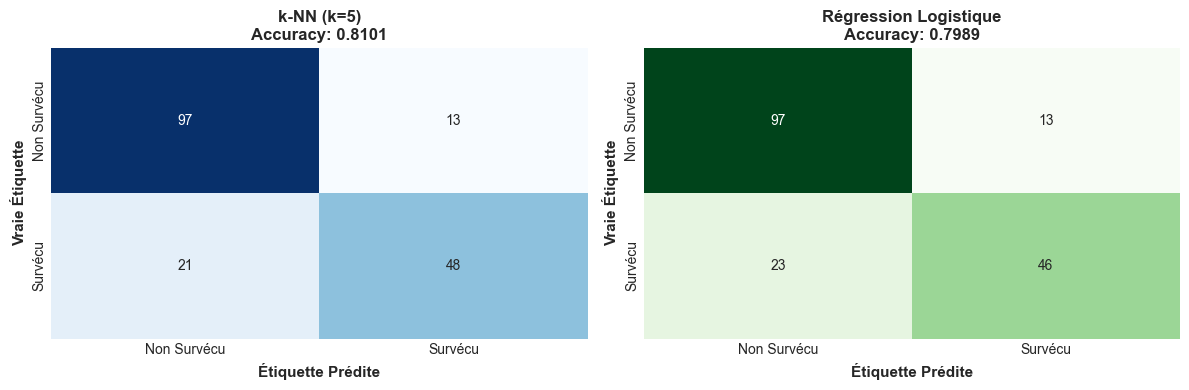

In [22]:
# Visualiser les deux matrices de confusion côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# k-NN
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Non Survécu', 'Survécu'],
            yticklabels=['Non Survécu', 'Survécu'],
            ax=axes[0], cbar_kws={'label': 'Nombre'})
axes[0].set_ylabel('Vraie Étiquette', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Étiquette Prédite', fontsize=11, fontweight='bold')
axes[0].set_title(f'k-NN (k=5)\nAccuracy: {acc_knn:.4f}', fontsize=12, fontweight='bold')

# Régression Logistique
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Non Survécu', 'Survécu'],
            yticklabels=['Non Survécu', 'Survécu'],
            ax=axes[1], cbar_kws={'label': 'Nombre'})
axes[1].set_ylabel('Vraie Étiquette', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Étiquette Prédite', fontsize=11, fontweight='bold')
axes[1].set_title(f'Régression Logistique\nAccuracy: {acc_lr:.4f}', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [23]:
# TODO: Afficher le rapport de classification

report_lr = classification_report(y_test, y_pred_lr, 
                                   target_names=['Non Survécu', 'Survécu'])

print("Rapport de Classification (Régression Logistique):")
print(report_lr)

Rapport de Classification (Régression Logistique):
              precision    recall  f1-score   support

 Non Survécu       0.81      0.88      0.84       110
     Survécu       0.78      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.80      0.80      0.80       179



## Comparaison des Modèles

In [24]:
# TODO: Créer une table de comparaison des deux modèles

comparison = pd.DataFrame({
    'Modèle': ['k-NN (k=5)', 'Régression Logistique'],
    'Accuracy': [acc_knn, acc_lr],
    'Vrais Positifs': [cm_knn[1,1], cm_lr[1,1]],
    'Faux Positifs': [cm_knn[0,1], cm_lr[0,1]],
    'Faux Négatifs': [cm_knn[1,0], cm_lr[1,0]],
    'Vrais Négatifs': [cm_knn[0,0], cm_lr[0,0]]
})

print("\nComparaison des Modèles:")
print(comparison.to_string(index=False))

# Meilleur modèle
best_model = 'k-NN (k=5)' if acc_knn > acc_lr else 'Régression Logistique'
best_acc = max(acc_knn, acc_lr)
print(f"\n✓ Meilleur modèle: {best_model} avec une accuracy de {best_acc:.4f}")


Comparaison des Modèles:
               Modèle  Accuracy  Vrais Positifs  Faux Positifs  Faux Négatifs  Vrais Négatifs
           k-NN (k=5)  0.810056              48             13             21              97
Régression Logistique  0.798883              46             13             23              97

✓ Meilleur modèle: k-NN (k=5) avec une accuracy de 0.8101


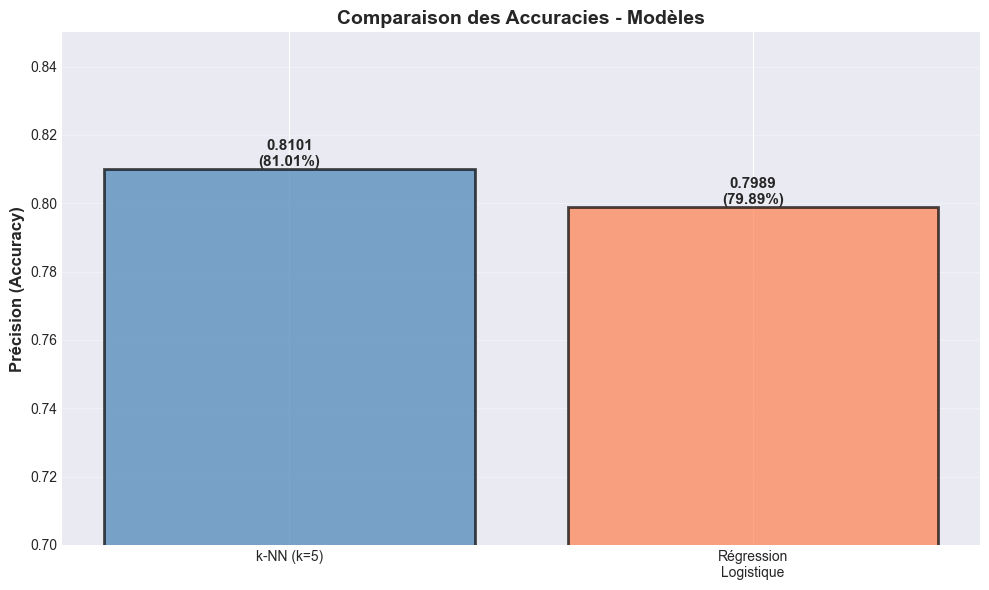

In [25]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(10, 6))
models = ['k-NN (k=5)', 'Régression\nLogistique']
accuracies = [acc_knn, acc_lr]
colors = ['steelblue', 'coral']

bars = ax.bar(models, accuracies, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Précision (Accuracy)', fontsize=12, fontweight='bold')
ax.set_title('Comparaison des Accuracies - Modèles', fontsize=14, fontweight='bold')
ax.set_ylim([0.7, 0.85])
ax.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.4f}\n({acc*100:.2f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Questions de Réflexion

### Question 1: Effet du Paramètre k
Pourquoi la précision de test augmente puis diminue quand on augmente k? Quel est le problème d'apprentissage associé?

### Question 2: Interprétation des Métriques
Dans la matrice de confusion, est-il plus grave pour ce problème du Titanic de:
- Prédire "survécu" pour quelqu'un qui n'a pas survécu (faux positif)?
- Prédire "non survécu" pour quelqu'un qui a survécu (faux négatif)?
Pourquoi?

### Question 3: Choix du Modèle
Sur la base de vos résultats, quel modèle préfériez-vous? Quels sont les critères de décision?

### Question 4: Amélioration
Quelles stratégies pourriez-vous utiliser pour améliorer la performance des modèles?
- Normalisation/Standardisation des features?
- Ajout de nouvelles features?
- Tuning d'autres hyperparamètres?


## Critères de Rendu

Votre atelier doit inclure:

1. **Nettoyage des données** (3 points)
   - Gestion correcte des valeurs manquantes
   - Encodage des variables catégoriques
   - Justification des choix

2. **Pipeline ML complet** (3 points)
   - Split train/test avec stratification
   - Entraînement des deux modèles
   - Évaluation complète (accuracy, confusion matrix, classification report)

3. **Analyse d'hyperparamètres** (2 points)
   - Variation du paramètre k
   - Graphique de performance vs k
   - Identification du k optimal

4. **Comparaison et Interprétation** (2 points)
   - Tableau de comparaison
   - Réponses aux questions de réflexion
   - Conclusions et recommandations


## Résultats finaux (démo)

En exécutant le notebook avec `random_state=42`:

- **k-NN (k=5)**
  - Accuracy: **0.8101** (81.01%)
  - Matrice de confusion: **[[97, 13], [21, 48]]**

- **Recherche du meilleur k** (k impairs de 1 à 21)
  - **k optimal = 7**
  - Meilleure accuracy test: **0.8156** (81.56%)

- **Régression Logistique**
  - Accuracy: **0.7989** (79.89%)
  - Matrice de confusion: **[[97, 13], [23, 46]]**

## Déductions

1. **Les deux modèles performent de façon proche**, avec un léger avantage pour k-NN.
2. **Le tuning de `k` apporte un gain mesurable** (k=7 > k=5), ce qui confirme l'importance de l'hyperparamétrage.
3. **Les faux négatifs restent significatifs** (passagers survivants prédits non survivants), donc le rappel de la classe `Survécu` est un axe d'amélioration.
4. **La standardisation des features est indispensable** pour k-NN (modèle basé sur les distances) et bénéfique pour la régression logistique.
5. Pour aller plus loin: validation croisée, ingénierie de features (ex: `family_size`, `title`), et recherche d'hyperparamètres plus systématique (`GridSearchCV`).

> Note: de légères variations peuvent apparaître selon la version des bibliothèques ou l'environnement d'exécution.